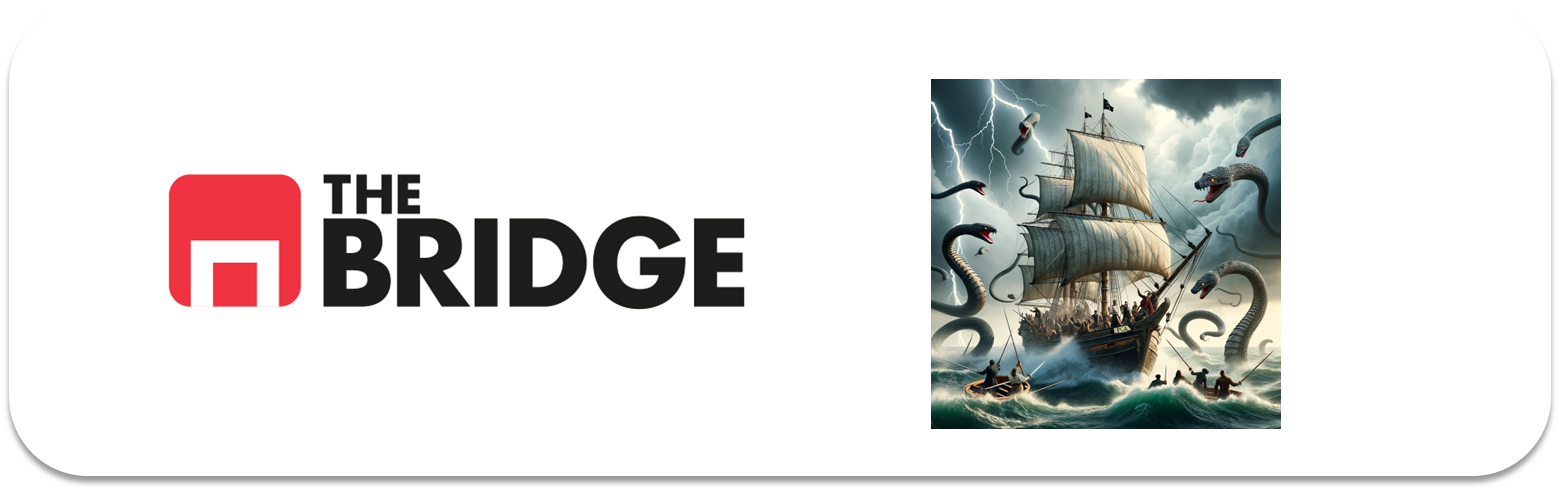

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técnicas de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import (SelectKBest, f_classif, mutual_info_classif,
                                        SelectFromModel, RFE, SequentialFeatureSelector)
from sklearn.decomposition import PCA


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (recall_score, classification_report,
                              ConfusionMatrixDisplay, accuracy_score, f1_score)

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


In [5]:
# Cargamos el dataset 

df = pd.read_csv('data/credit_npo.csv')
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
12532,0,0.197116,59,0,0.290216,5140.0,6,0,1,0,0.0
12533,0,0.036726,62,0,0.884985,5833.0,12,0,1,0,0.0
12534,0,0.120313,49,0,0.577676,6333.0,7,0,2,0,2.0
12535,0,0.252566,63,0,0.037640,14000.0,9,0,0,0,1.0


In [7]:
df.info() # Hay nulos en algunas variables y todas ellas, en principio, son numéricas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [11]:
# Valores nulos por variable
# MonthlyIncome tiene 721 nulos y NumberOfDependents tiene 177                 

print(df.isnull().sum())
print(f"\nTotal filas con nulos: {df.isnull().any(axis=1).sum()}")

SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64

Total filas con nulos: 721


In [ ]:
# Eliminamos los nulos
# Hacemos un .info() para confirmar que no hay ya datos faltantes

df_clean = df.dropna().copy()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11816 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      11816 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  11816 non-null  float64
 2   age                                   11816 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  11816 non-null  int64  
 4   DebtRatio                             11816 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       11816 non-null  int64  
 7   NumberOfTimes90DaysLate               11816 non-null  int64  
 8   NumberRealEstateLoansOrLines          11816 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  11816 non-null  int64  
 10  NumberOfDependents                    11816 non-null  float64
dtypes: float64(4), int64

In [14]:
df_clean.describe()

# En estos datos se ven algunos valores dispares en las variables numéricas
# Esto indica que vamos a tener que escalar seguramente 

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,11816.000000,11816.000000,11816.000000,11816.000000,11816.000000,11816.000000,11816.000000,11816.000000,11816.000000,11816.000000,11816.000000
mean,0.070244,0.335668,51.447698,0.340471,0.499708,6864.815420,8.759140,0.180010,1.059580,0.149712,0.856804
std,0.255568,0.365209,14.516270,2.927409,2.696067,11855.905437,5.129772,2.892577,1.140716,2.868248,1.147509
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.034927,41.000000,0.000000,0.143456,3498.750000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.179183,51.000000,0.000000,0.294748,5416.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.587187,62.000000,0.000000,0.477414,8300.000000,11.000000,0.000000,2.000000,0.000000,2.000000
max,1.000000,6.000000,101.000000,98.000000,96.000000,702500.000000,49.000000,98.000000,19.000000,98.000000,10.000000


In [15]:
# Convertimos categóricas en otras columnas dividas en varios niveles 

# NumberOfTime30-59DaysPastDueNotWorse -> 3 niveles: 0, 1-2, 3+

df_clean['PastDue30_59'] = pd.cut(
    df_clean['NumberOfTime30-59DaysPastDueNotWorse'],
    bins=[-1, 0, 2, np.inf], labels=[0, 1, 2]
).astype(int)

# NumberOfTimes90DaysLate -> 2 niveles: 0 vs 1+

df_clean['PastDue90'] = (df_clean['NumberOfTimes90DaysLate'] > 0).astype(int)

# NumberOfTime60-89DaysPastDueNotWorse -> 2 niveles: 0 vs 1+

df_clean['PastDue60_89'] = (df_clean['NumberOfTime60-89DaysPastDueNotWorse'] > 0).astype(int)

In [17]:
# Eliminar columnas originales sustituidas

cols_originales = ['NumberOfTime30-59DaysPastDueNotWorse',
                   'NumberOfTimes90DaysLate',
                   'NumberOfTime60-89DaysPastDueNotWorse']
df_clean.drop(columns=cols_originales, inplace=True)

In [20]:
df_clean.info() # Aquí ya vemos las columnas nuevas sin las columnas eliminadas

<class 'pandas.core.frame.DataFrame'>
Index: 11816 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      11816 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  11816 non-null  float64
 2   age                                   11816 non-null  int64  
 3   DebtRatio                             11816 non-null  float64
 4   MonthlyIncome                         11816 non-null  float64
 5   NumberOfOpenCreditLinesAndLoans       11816 non-null  int64  
 6   NumberRealEstateLoansOrLines          11816 non-null  int64  
 7   NumberOfDependents                    11816 non-null  float64
 8   PastDue30_59                          11816 non-null  int64  
 9   PastDue90                             11816 non-null  int64  
 10  PastDue60_89                          11816 non-null  int64  
dtypes: float64(4), int64

In [22]:
# Definir features y target

target = 'SeriousDlqin2yrs'
features = [c for c in df_clean.columns if c != target]

num_features = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
                'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
                'NumberRealEstateLoansOrLines', 'NumberOfDependents']
cat_features = ['PastDue30_59', 'PastDue90', 'PastDue60_89']

print(f"\nFeatures numéricas: {num_features}")
print(f"Features categóricas: {cat_features}")


Features numéricas: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents']
Features categóricas: ['PastDue30_59', 'PastDue90', 'PastDue60_89']


In [23]:
# Split entre train y test 

X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
    )

In [25]:
print(X_train.shape)

(9452, 10)


In [26]:
print(y_train.shape)

(9452,)


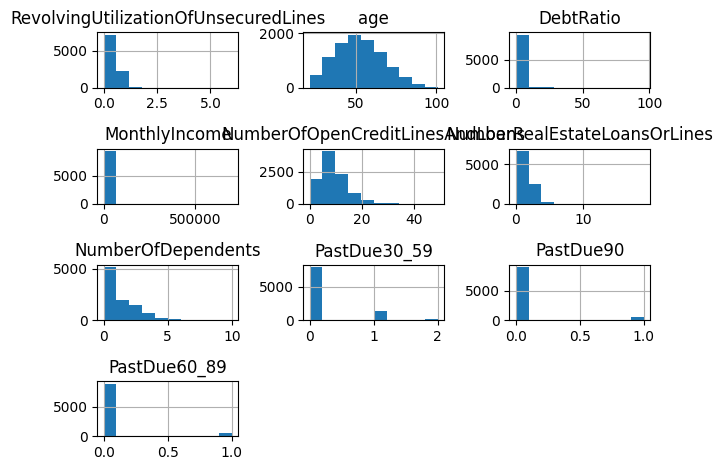

In [ ]:
# Ploteamos con histogramas el dataset de entrenamiento y vemos órdenes de magnitud muy alejados
# Va a ser necesario escalar 

X_train.hist()
plt.tight_layout()

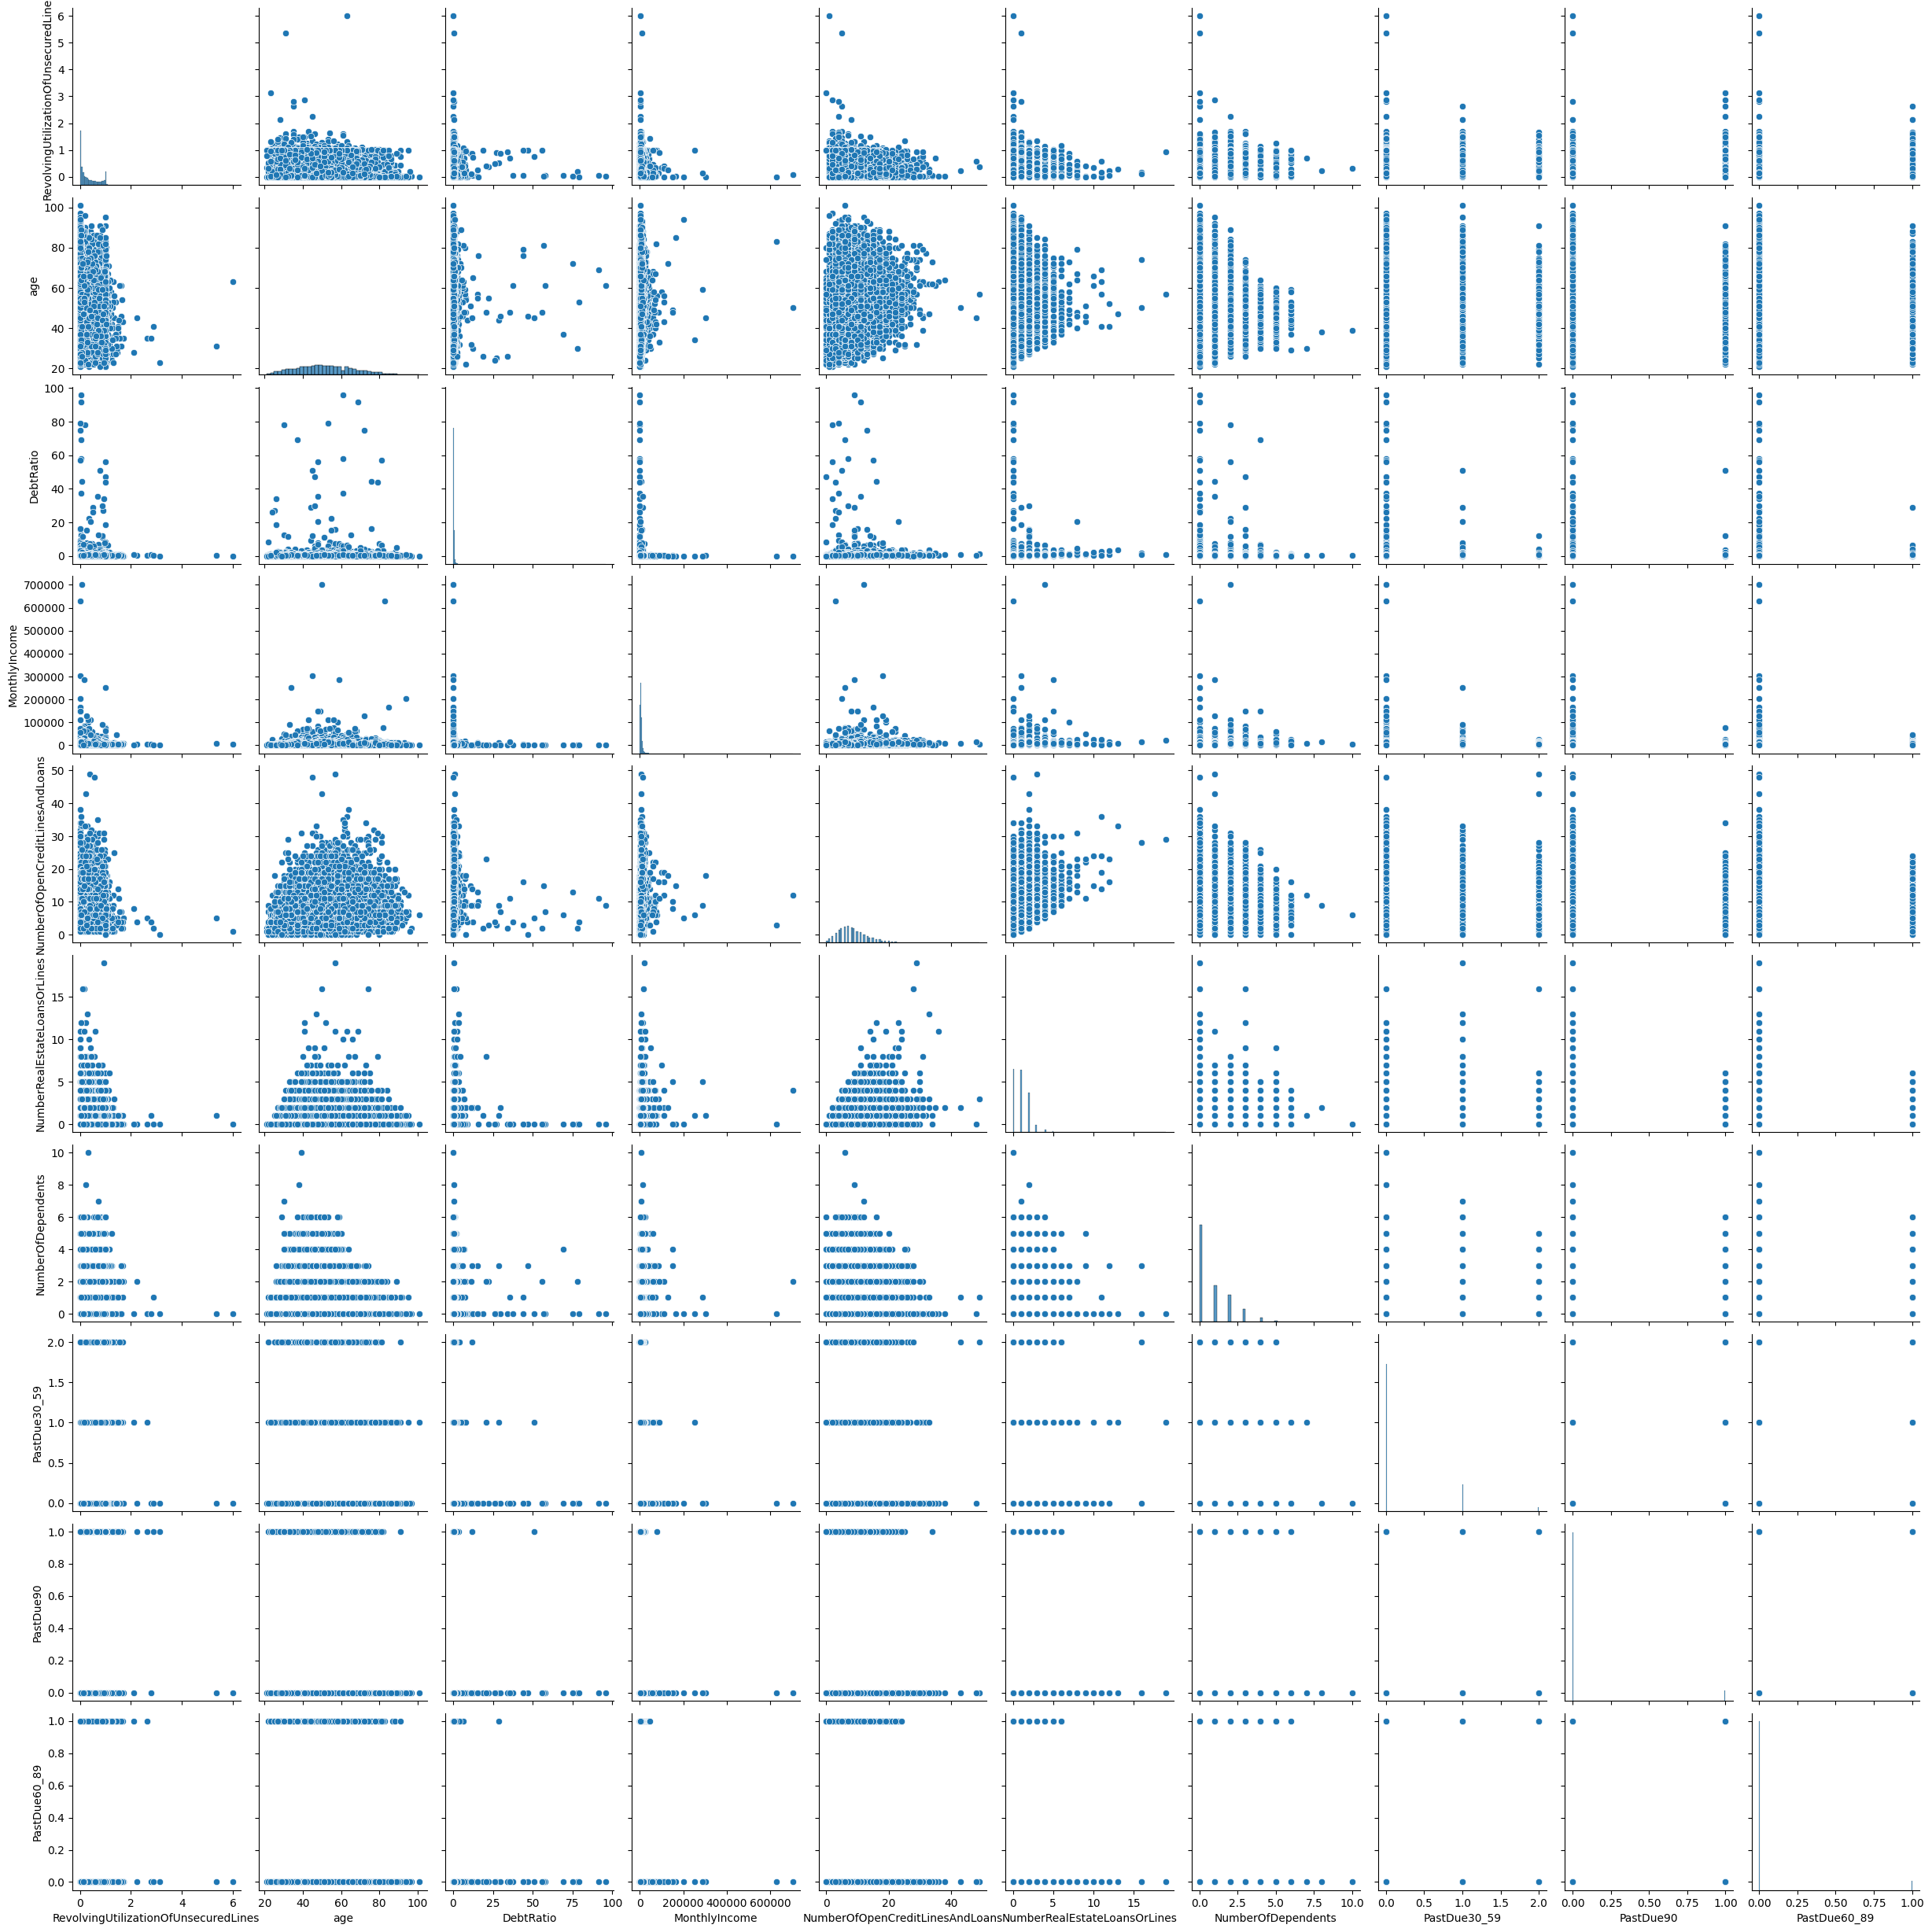

In [31]:
sns.pairplot(X_train)

In [29]:
# Escalamos las variables

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=features, index=X_test.index)

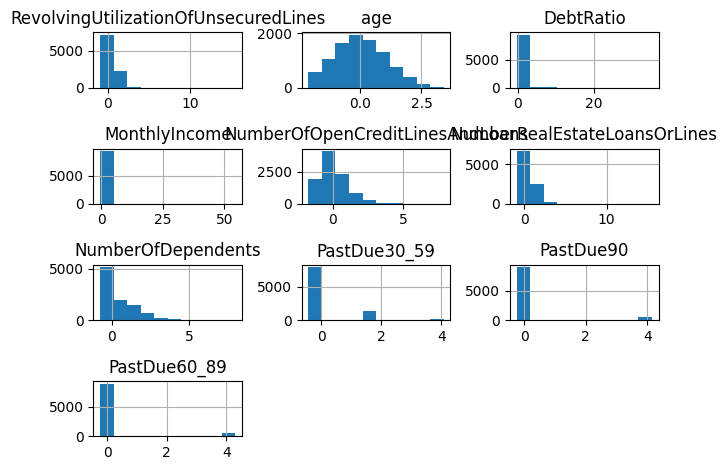

In [38]:
X_train_scaled.hist() # Aquí ya vemos una dstribución en órdenes de magnitud más o menos simulares 
plt.tight_layout()

#### **1. Seleccionamos las 6 con mayor correlación absoluta con el target**


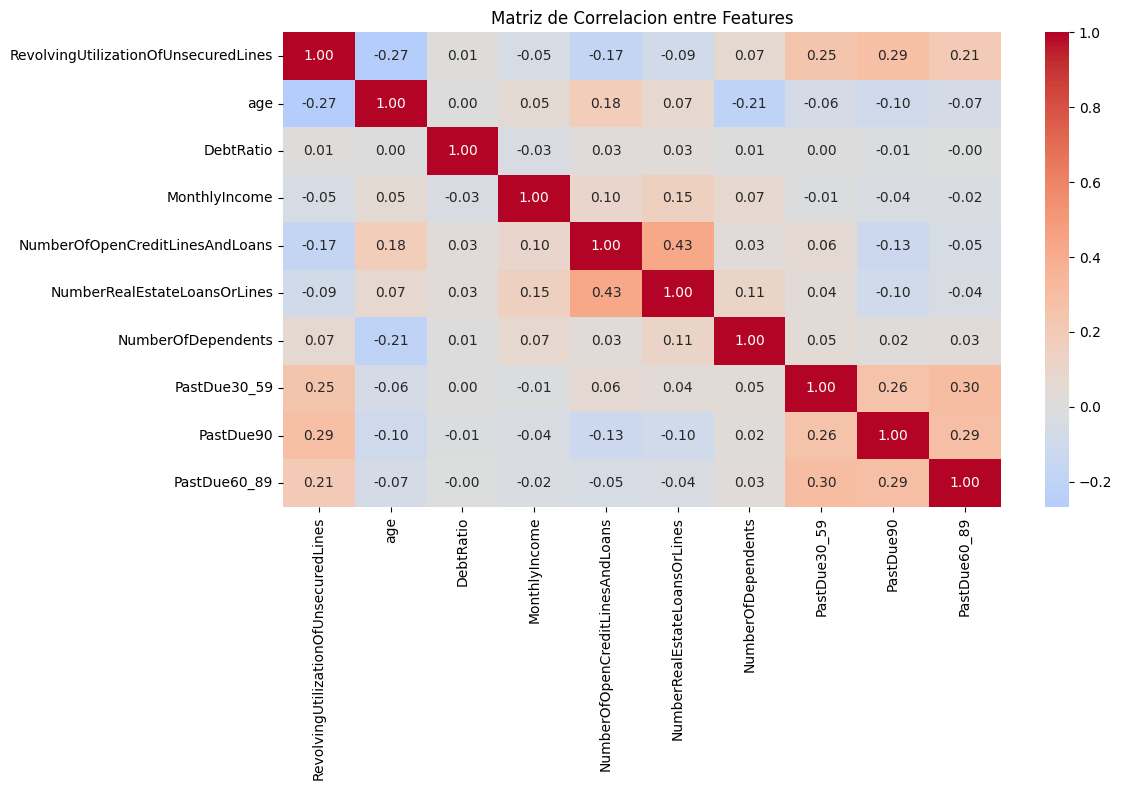

In [ ]:
# Matriz de correlación

plt.figure(figsize=(12, 8))
corr = X_train.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlacion entre Features')
plt.tight_layout()
plt.show()


In [40]:
# Correlacion con el target

corr_target = df_clean[features + [target]].corr()[target].drop(target).abs().sort_values(ascending=False)
print("\nCorrelacion absoluta con el target:")
print(corr_target)

# Varianza sobre datos escalados

varianza = X_train_scaled.var().sort_values(ascending=False)
print("\nVarianza (escalada):")
print(varianza)


Correlacion absoluta con el target:
PastDue90                               0.345576
RevolvingUtilizationOfUnsecuredLines    0.280350
PastDue30_59                            0.252499
PastDue60_89                            0.251664
age                                     0.106076
NumberOfDependents                      0.043825
NumberOfOpenCreditLinesAndLoans         0.029574
MonthlyIncome                           0.022199
DebtRatio                               0.001666
NumberRealEstateLoansOrLines            0.001321
Name: SeriousDlqin2yrs, dtype: float64

Varianza (escalada):
RevolvingUtilizationOfUnsecuredLines    1.000106
age                                     1.000106
MonthlyIncome                           1.000106
NumberOfOpenCreditLinesAndLoans         1.000106
NumberRealEstateLoansOrLines            1.000106
NumberOfDependents                      1.000106
PastDue30_59                            1.000106
DebtRatio                               1.000106
PastDue90           

In [54]:
# Seleccionamos las 6 con mayor correlación absoluta con el target

max_features = 6

features_corr = corr_target.head(max_features).index.tolist()
print(f"Selección porCorrelación y Varianza: {features_corr}")

Selección porCorrelación y Varianza: ['PastDue90', 'RevolvingUtilizationOfUnsecuredLines', 'PastDue30_59', 'PastDue60_89', 'age', 'NumberOfDependents']


#### **2. Selección de features numéricas mediante SelectKBest y ANOVA y features categóricas mediante Mutual Information**

In [50]:
# ANOVA F-test para features numericas

skb_anova = SelectKBest(f_classif, k='all')
skb_anova.fit(X_train_scaled[num_features], y_train)
anova_scores = pd.Series(skb_anova.scores_, index=num_features).sort_values(ascending=False)
print(anova_scores)

RevolvingUtilizationOfUnsecuredLines    788.269908
age                                     105.857431
NumberOfDependents                       20.125285
NumberOfOpenCreditLinesAndLoans          10.626153
MonthlyIncome                             6.124270
NumberRealEstateLoansOrLines              0.314679
DebtRatio                                 0.000074
dtype: float64


In [51]:
# Mutual Information para features categóricas

skb_mi = SelectKBest(mutual_info_classif, k='all')
skb_mi.fit(X_train[cat_features], y_train)
mi_scores = pd.Series(skb_mi.scores_, index=cat_features).sort_values(ascending=False)
print(mi_scores)

PastDue90       0.027646
PastDue30_59    0.019202
PastDue60_89    0.016712
dtype: float64


In [65]:
# Aplicamos un MinMaxScaler tener los dos scores entre 0 y 1 y compararlos 

anova_norm = (anova_scores - anova_scores.min()) / (anova_scores.max() - anova_scores.min() + 1e-10)
mi_norm = (mi_scores - mi_scores.min()) / (mi_scores.max() - mi_scores.min() + 1e-10)
scores_m2 = pd.concat([anova_norm, mi_norm]).sort_values(ascending=False)

anv_min_features = scores_m2.head(max_features).index.tolist()
print(f"Selección por NOVA y Mutual Information: {anv_min_features}")

Selección por NOVA y Mutual Information: ['RevolvingUtilizationOfUnsecuredLines', 'PastDue90', 'PastDue30_59', 'age', 'NumberOfDependents', 'NumberOfOpenCreditLinesAndLoans']


#### **3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)**

In [59]:
# Usamos un modelo Random Forest
# 
rf_base = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
sfm = SelectFromModel(rf_base, max_features=max_features, threshold=-np.inf)
sfm.fit(X_train_scaled, y_train)

rf_features = X_train_scaled.columns[sfm.get_support()].tolist()
importances = pd.Series(sfm.estimator_.feature_importances_, index=features).sort_values(ascending=False)
print("Ratio de Feature Importances para el modelo):")
print(importances)
print(f"Selección de features mediante Random Forest: {rf_features}")

Ratio de Feature Importances para el modelo):
RevolvingUtilizationOfUnsecuredLines    0.196788
DebtRatio                               0.163549
MonthlyIncome                           0.153928
age                                     0.124493
NumberOfOpenCreditLinesAndLoans         0.102995
PastDue90                               0.090184
NumberOfDependents                      0.048260
NumberRealEstateLoansOrLines            0.044304
PastDue60_89                            0.039344
PastDue30_59                            0.036154
dtype: float64
Selección de features mediante Random Forest: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'PastDue90']


#### **4. Selección de las mejores features empleando RFE**

In [60]:
lr_base = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=lr_base, n_features_to_select=max_features, step=1)
rfe.fit(X_train_scaled, y_train)

rfe_features = X_train_scaled.columns[rfe.support_].tolist()
ranking_rfe = pd.Series(rfe.ranking_, index=features).sort_values()
print("Ranking de features con RFE:")
print(ranking_rfe)
print(f"Selección de features con RFE: {rfe_features}")

Ranking de features con RFE:
RevolvingUtilizationOfUnsecuredLines    1
age                                     1
MonthlyIncome                           1
NumberRealEstateLoansOrLines            1
PastDue30_59                            1
PastDue90                               1
PastDue60_89                            2
NumberOfOpenCreditLinesAndLoans         3
NumberOfDependents                      4
DebtRatio                               5
dtype: int64
Selección de features con RFE: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'NumberRealEstateLoansOrLines', 'PastDue30_59', 'PastDue90']


#### **5. Selección de las mejores features empleando SFS**

In [64]:
lr_sfs = LogisticRegression(max_iter=1000, random_state=42)
sfs = SequentialFeatureSelector(
    lr_sfs, 
    n_features_to_select=max_features,
    direction='forward', 
    cv=3, 
    scoring='balanced_accuracy', 
    n_jobs=-1
)

sfs.fit(X_train_scaled, y_train)

sfs_features = X_train_scaled.columns[sfs.get_support()].tolist()
print(f"Selección de features con SFS: {sfs_features}")

Selección de features con SFS: ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome', 'NumberRealEstateLoansOrLines', 'NumberOfDependents', 'PastDue90']


#### **6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores**

In [67]:
metodos = {
    'Selección por Correlación y Varianza': features_corr,
    'Selección Anova y Mutual Information': anv_min_features,
    'Selección Random Forest': rf_features,
    'Selección RFE': rfe_features,
    'Selección SFS': sfs_features,
}

votes = pd.DataFrame(index=features)
for nombre, lista in metodos.items():
    votes[nombre] = votes.index.isin(lista).astype(int)
votes['Total'] = votes.sum(axis=1)
votes = votes.sort_values('Total', ascending=False)

print("\nTabla de votacion:")
display(votes)

hard_voting_features = votes.head(max_features).index.tolist()
print(f"Selección de Features por Hard Voting: {hard_voting_features}")


Tabla de votacion:


,Selección por Correlación y Varianza,Selección Anova y Mutual Information,Selección Random Forest,Selección RFE,Selección SFS,Total
RevolvingUtilizationOfUnsecuredLines,1,1,1,1,1,5
PastDue90,1,1,1,1,1,5
age,1,1,1,1,0,4
MonthlyIncome,0,0,1,1,1,3
NumberOfDependents,1,1,0,0,1,3
PastDue30_59,1,1,0,1,0,3
NumberRealEstateLoansOrLines,0,0,0,1,1,2
NumberOfOpenCreditLinesAndLoans,0,1,1,0,0,2
DebtRatio,0,0,1,0,1,2
PastDue60_89,1,0,0,0,0,1


Selección de Features por Hard Voting: ['RevolvingUtilizationOfUnsecuredLines', 'PastDue90', 'age', 'MonthlyIncome', 'NumberOfDependents', 'PastDue30_59']


#### **Lista completa de selección de features por método**

In [68]:
all_feature_lists = {
    'Selección por Correlación y Varianza': features_corr,
    'Selección Anova y Mutual Information': anv_min_features,
    'Selección Random Forest': rf_features,
    'Selección RFE': rfe_features,
    'Selección SFS': sfs_features,
    'Selección por Hard Voting': hard_voting_features,
}

for nombre, lista in all_feature_lists.items():
    print(f"  {nombre:15s}: {lista}")

  Selección por Correlación y Varianza: ['PastDue90', 'RevolvingUtilizationOfUnsecuredLines', 'PastDue30_59', 'PastDue60_89', 'age', 'NumberOfDependents']
  Selección Anova y Mutual Information: ['RevolvingUtilizationOfUnsecuredLines', 'PastDue90', 'PastDue30_59', 'age', 'NumberOfDependents', 'NumberOfOpenCreditLinesAndLoans']
  Selección Random Forest: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'PastDue90']
  Selección RFE  : ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'NumberRealEstateLoansOrLines', 'PastDue30_59', 'PastDue90']
  Selección SFS  : ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome', 'NumberRealEstateLoansOrLines', 'NumberOfDependents', 'PastDue90']
  Selección por Hard Voting: ['RevolvingUtilizationOfUnsecuredLines', 'PastDue90', 'age', 'MonthlyIncome', 'NumberOfDependents', 'PastDue30_59']


### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.